# Quaks News Analyst

In [1]:
%%capture
import os
import nest_asyncio
from IPython.display import Markdown, display
from dotenv import load_dotenv
from notebooks import experiment_utils
from app.core.container import Container
from app.interface.api.messages.schema import MessageRequest

os.chdir("..")
load_dotenv()
nest_asyncio.apply()

# start dependency injection container
container = Container()
container.init_resources()
container.wire(modules=[__name__])

# get checkpointer instance
graph_persistence_factory = container.graph_persistence_factory()
checkpointer = graph_persistence_factory.build_checkpoint_saver()

# Create Workflow
xai_agent = experiment_utils.create_xai_agent(
    agent_type="quaks_news_analyst", llm_tag="grok-4-1-fast-non-reasoning", api_key=os.getenv("XAI_API_KEY")
)
xai_news_analyst = container.quaks_news_analyst_agent()
xai_workflow_builder = xai_news_analyst.get_workflow_builder(xai_agent["id"])
xai_workflow = xai_workflow_builder.compile(checkpointer=checkpointer)

### Display Workflow Graph

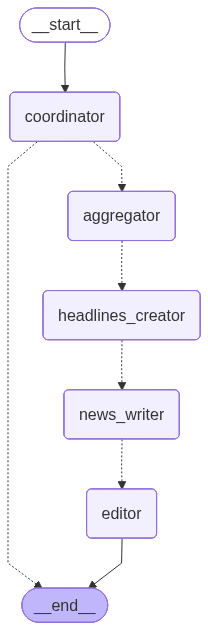

In [2]:
experiment_utils.print_graph(xai_workflow)

---

## Invoke quaks-news-analyst

In [3]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="Generate news insights.",
    agent_id=xai_agent["id"],
)

inputs = xai_news_analyst.get_input_params(message, schema="public")
config = xai_news_analyst.get_config(xai_agent["id"])
result = xai_workflow.invoke(inputs, config)
ai_message_content, workflow_state = xai_news_analyst.format_response(result)

---

###

In [4]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

# Quaks Investor Briefing — Tue Mar 10 2026

> Markets rebounded modestly amid President Trump's signals that the U.S. campaign against Iran may be nearing completion, easing oil volatility fears while earnings beats in uranium and industrials supported selective risk-on rotation.

## Office REITs Face Liquidity Crunch Amid Strategic Overhauls
Franklin Street Properties (FSP) updated on its May 2025 strategic review with Bank of America Securities during its Q4 call, evaluating portfolio sales, asset disposals, JVs, corporate deals, liquidations, and refinancing. Completed a $320M TPG credit facility (Feb 27) repaying $249M prior debt, adding $45M delayed draw for leasing; suspended dividends to save $4.1M/year, cut G&A 10% YoY to $12.4M. Leased occupancy hit 88.5% (ex-Oakland), up 680bps YoY, with NOI improving. Creative Media (CMCT) redeemed $153M preferred into common (FFO boost $16M/year), sold lending unit for $31M net cash, targeting multifamily focus amid 88.4% occupancy gains.

Office transaction volumes languish at $80-90B annually (vs. pre-pandemic $140-150B) due to rate hikes and institutional pullback; buyer pools selective, debt constrained, favoring opportunistic capital and distressed sales (e.g., Denver CBD). FSP/CMCT moves enhance flexibility via refinancings/debt retirement, positioning for leasing-driven stabilization despite thin markets. Investors should monitor FSP process outcomes (no timing assured) and CMCT hotel refinance post-renovation for liquidity unlocks.

Key watch: Q1 leasing velocity (target 90%+ occupancy), debt maturities (FSP April avoided), national office volumes/debt trends for transaction thaw. Strategic resolutions could catalyze 20-30% NAV upside if asset sales materialize at replacement cost levels.

## Uranium Momentum Builds on UEC's Sales Beat, Production Ramps
Uranium Energy (UEC) Q2 revenue crushed $20.2M vs. $5M est. on 200k lb U3O8 sales at $101/lb avg (above $80.76 spot), generating $10M gross profit; produced 45k lb at $44 total/$40 cash cost. Burke Hollow ISR complete (startup pending), Wyoming capacity expanded (4 new headers); $818M liquidity/no debt, 1.456M lb inventory ($144M mkt value). Core FFO negative but operational trends improving.

UEC exemplifies uranium supply tightness amid nuclear revival (60GW+ reactors building), with premium contracts and restarts signaling multi-year tailwinds. Zero debt/strong liquidity de-risks execution vs. leveraged peers; inventory supports steady sales as spot firms ~$81. Sector beat reinforces domestic production push.

Track Burke Hollow approval/Wyoming ramps for Q3 output surge (to 4M+ lb/yr); spot/futures for restart triggers. FY2026 guide refinement post-Q3 could drive 25-40% upside if prices hold $80+.

## AI Partnerships Ignite Quantum, Edge Momentum for AMD Ecosystem
Xanadu (CHAC SPAC) AMD collab demos hybrid quantum-CFD (20 qubits/35M gates, 25x GPU speedup), advancing aerospace/engineering apps ahead of March 19 vote ($500M proceeds). BlackBerry QNX 8.0 integrates AMD Ryzen V2000/P100 for reliable edge AI in autos/robots/medical. Micron +533% YoY on HBM3E AI memory (PTs $525-550); Applied/Micron $5B EPIC center accelerates DRAM/HBM scaling ($135B 2026 wafer equip mkt).

AMD's ecosystem gains validate hybrid quantum/edge AI viability amid export scrutiny; CHAC nears public debut. Micron captures AI infra spend (~7x fwd P/E vs NVDA); Applied's facility supports capacity crunch.

Watch CHAC close/Q1 performance; Micron HBM sales/FY2026 $76B guide; Applied customer ramps. Geopolitics/export rules key risks, but partnerships signal 20-30% sector upside.

## Biotech Swings on FDA Shift, Earnings; Regulatory Tailwinds Emerge
FDA CBER head Prasad resigns April, boosting uniQure (QURE +26%), Capricor (CAPR +17%, Deramiocel PDUFA Aug), Regenxbio (RGNX), Solid Biosciences (SLDB); Zevra (ZVRA +17% Q4 beat + GeneDx), HeartBeam (BEAT +6% Mount Sinai AI-ECG), AtaiBeckley (ATAI +6% BPL-003 upgrades). BioNTech (BNTX -14%) on mRNA pivot (FY26 sales miss), Inspired (INSE -182% EPS miss).

Prasad's exit eases gene therapy hurdles post-CRLs; partnerships validate AI/testing demand. BNTX risks pipeline delays; earnings misses highlight volatility.

Monitor CAPR PDUFA, QURE path; BNTX successor impact. FDA flexibility + AI catalysts could lift 25-50% in winners.

## Earnings Outlook: ORCL Cloud/AI Guidance Critical Post-Market
March 10 pre-open: KSS ($0.85/$5.14B), NIO (-$0.05/$4.61B), UNFI ($0.51/$8.12B). Post-close ORCL ($1.55/$16.9B) key for cloud bookings amid $45-50B capex. Prior beats (UEC) vs. misses (INSE) set tone.

ORCL AI guidance to signal infra spend sustainability; consumer tests (KSS/NIO) gauge spending resilience.

Focus ORCL bookings/guidance; beats for rotation, misses for volatility.

---
*Report generated by Quaks News Analyst*